In [2]:
"""
Quark/Gluon Jet Classification  —  JetGLADC v2 (optimised)
=============================================================
Architecture: Stable-ChebNet encoder  +  GLADC perturbed dual-encoder
              +  NT-Xent contrastive loss  +  binary classification head

──────────────────────────────────────────────────
1. LR schedule : OneCycleLR (warm-up → peak → cosine anneal) replaces
                 plain CosineAnnealingLR that decayed too aggressively.
                 Peak LR raised to 3e-3 so early epochs train faster.

2. Batch size  : 64 → shorter epoch time, smoother gradients, better
                 NT-Xent negatives (more in-batch negatives per step).

3. Architecture: hidden 64 → 128, deeper classifier (3 layers + BN),
                 global_mean_pool concatenated with global_max_pool
                 (dual-pool) for richer graph representation.

4. BatchNorm   : added after every ChebNet layer → stable, faster convergence.

5. Contrastive weight warmup : λ starts at 0, ramps to CONTRASTIVE_W over
                 WARMUP_EPOCHS so the CE loss leads early training,
                 then contrastive regularisation kicks in once the encoder
                 has learned something meaningful.

6. Temperature : τ reduced 0.5 → 0.15 — tighter contrastive objective,
                 better cluster separation.

7. Residual skip in encoder : X_out = LayerNorm(X_in + Δ) prevents
                 vanishing updates in deeper/wider networks.

8. Weight init : Kaiming (ELU-aware) on all linear layers.

9. Early stopping : patience=10 on val AUC — avoids wasted epochs if
                 the model has converged.

10. Gradient clipping : 2.0 (was 1.0) — less aggressive, lets larger
                 useful gradients through.
"""

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG 
# ══════════════════════════════════════════════════════════════════════════════
DATASET_PATH   = r"D:\Evaluation Test Genie\Data\jet_pyg_dataset.pt"

# Stable-ChebNet
CHEB_K         = 3        # K=3 balances long-range vs speed (K=4 was slow)
CHEB_LAYERS    = 4        # deeper encoder compensates for lower K
HIDDEN_DIM     = 128      # wider hidden dim
EPS_EULER      = 0.1      # forward-Euler step  ε
GAMMA          = 0.01     # stability damping  γ
SIGMA_NOISE    = 0.02     # slightly larger perturbation for harder positives

# Projection head & contrastive loss
PROJ_DIM       = 64
TEMPERATURE    = 0.15     # tighter contrastive clusters

# Classifier
CLASSIFIER_DIM = 256      # wider classifier head

# Training
TRAIN_RATIO    = 0.70
VAL_RATIO      = 0.15
BATCH_SIZE     = 64       # larger batch → more NT-Xent negatives
LR_PEAK        = 3e-3     # OneCycleLR peak
LR_DIV         = 10.0     # initial LR = LR_PEAK / LR_DIV
LR_FINAL_DIV   = 1e4      # final LR = LR_PEAK / LR_FINAL_DIV
WEIGHT_DECAY   = 1e-4
EPOCHS         = 80       # more epochs, early stopping prevents over-run
WARMUP_EPOCHS  = 8        # epochs before contrastive loss reaches full weight
CONTRASTIVE_W  = 0.2      # final λ (lower — CE drives accuracy)
PATIENCE       = 12       # early stopping patience on val AUC

SEED           = 42


### INSTALL ALL DEPENDENCIES 

In [4]:
import torch

# !pip install -q --upgrade pip
# !pip install -q torch torchvision torchaudio
# !pip install -q torch-geometric
# TORCH = torch.__version__

# !pip install -q pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv \-f https://data.pyg.org/whl/torch-{TORCH}.html

# !pip install -q numpy

print("All dependencies installed successfully!")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

import time, random
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_max_pool, global_mean_pool
from torch_scatter import scatter

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[config] device = {DEVICE}")

All dependencies installed successfully!
Torch version: 2.5.1
CUDA available: True
[config] device = cuda


══════════════════════════════════════════════════════════════════════════════
##### 1.  DATASET
══════════════════════════════════════════════════════════════════════════════

In [5]:
class JetDataset(InMemoryDataset):
    def __init__(self, path):
        super().__init__(root=None)
        data_obj, slices = torch.load(path, map_location="cpu",
                                      weights_only=False)
        self.data, self.slices = data_obj, slices
    def _download(self): pass
    def _process(self):  pass


def load_and_split(path):
    print(f"[data] loading {path} …")
    dataset = JetDataset(path)
    N = len(dataset)
    in_dim = dataset[0].x.shape[1]
    print(f"[data] {N:,} graphs  |  node-feat dim={in_dim}")

    g = torch.Generator().manual_seed(SEED)
    idx = torch.randperm(N, generator=g)
    n_tr = int(N * TRAIN_RATIO)
    n_vl = int(N * VAL_RATIO)

    tr = dataset[idx[:n_tr].tolist()]
    vl = dataset[idx[n_tr:n_tr+n_vl].tolist()]
    te = dataset[idx[n_tr+n_vl:].tolist()]
    print(f"[data] train={len(tr)}  val={len(vl)}  test={len(te)}")
    return tr, vl, te


══════════════════════════════════════════════════════════════════════════════
##### 2.  CHEBYSHEV BASIS  (sparse, no eigendecomp)
══════════════════════════════════════════════════════════════════════════════

In [6]:
def chebyshev_basis(edge_index, edge_weight, num_nodes, K, x):
    """
    Returns [T_0(L̃)x, …, T_K(L̃)x] via 3-term recurrence.
    L̃ = I − D^{-½} A D^{-½}
    """
    row, col = edge_index
    deg  = scatter(edge_weight, row, dim=0,
                   dim_size=num_nodes, reduce="sum").clamp(min=1e-8)
    norm = (deg[row] * deg[col]).sqrt()
    w    = edge_weight / norm                          # D^{-½}AD^{-½} weights

    def prop(h):
        return scatter(w.unsqueeze(-1) * h[col],
                       row, dim=0, dim_size=num_nodes, reduce="sum")

    def lap(h):
        return h - prop(h)

    basis  = []
    t0, t1 = x, lap(x)
    basis.append(t0)
    if K >= 1:
        basis.append(t1)
    for _ in range(2, K + 1):
        t2 = 2.0 * lap(t1) - t0
        basis.append(t2)
        t0, t1 = t1, t2
    return basis

══════════════════════════════════════════════════════════════════════════════
##### 3.  STABLE-CHEBNET LAYER
#####     X^(l+1) = LayerNorm( X^(l) + ε · Σ_k T_k(L̃)X^(l)(W_k − W_kᵀ − γI) )
══════════════════════════════════════════════════════════════════════════════


In [7]:
class StableChebNetLayer(nn.Module):
    def __init__(self, in_dim, out_dim, K,
                 eps=EPS_EULER, gamma=GAMMA):
        super().__init__()
        self.K, self.eps, self.gamma = K, eps, gamma
        self.proj = nn.Linear(in_dim, out_dim, bias=False)
        self.W    = nn.ParameterList([
            nn.Parameter(torch.empty(out_dim, out_dim)) for _ in range(K+1)
        ])
        self.bn   = nn.BatchNorm1d(out_dim)    
        self.norm = nn.LayerNorm(out_dim)      
        self._init()

    def _init(self):
        nn.init.kaiming_uniform_(self.proj.weight, nonlinearity="leaky_relu")
        for w in self.W:
            nn.init.xavier_uniform_(w)

    def antisym(self, w):
        return w - w.t() - self.gamma * torch.eye(
            w.size(0), device=w.device, dtype=w.dtype)

    def forward(self, x, edge_index, edge_weight, num_nodes):
        h = self.proj(x)                                  # (N, out_dim)
        h = self.bn(h)
        basis = chebyshev_basis(edge_index, edge_weight, num_nodes, self.K, h)
        delta = torch.zeros_like(h)
        for T_k_h, w_raw in zip(basis, self.W):
            delta = delta + T_k_h @ self.antisym(w_raw).t()
        return self.norm(h + self.eps * delta)            # residual + LN


══════════════════════════════════════════════════════════════════════════════
##### 4.  ENCODER  (stack of Stable-ChebNet layers + dual pool)
══════════════════════════════════════════════════════════════════════════════

In [8]:
class StableChebNetEncoder(nn.Module):
    def __init__(self, in_dim, hidden, K, n_layers, eps=EPS_EULER, gamma=GAMMA):
        super().__init__()
        dims = [in_dim] + [hidden] * n_layers
        self.layers = nn.ModuleList([
            StableChebNetLayer(dims[i], dims[i+1], K, eps, gamma)
            for i in range(n_layers)
        ])
        self.act = nn.ELU()

    def forward(self, x, edge_index, edge_weight, batch):
        n = x.size(0)
        for layer in self.layers:
            x = self.act(layer(x, edge_index, edge_weight, n))
        z_node  = x
        # Dual pool: concat max + mean → richer global descriptor
        z_graph = torch.cat([
            global_max_pool(z_node, batch),
            global_mean_pool(z_node, batch),
        ], dim=-1)                                        # (B, 2*hidden)
        return z_node, z_graph


══════════════════════════════════════════════════════════════════════════════
##### 5.  DUAL-GRAPH ENCODER  (GLADC perturbed encoder, autograd-safe)
══════════════════════════════════════════════════════════════════════════════

In [9]:
class DualGraphEncoder(nn.Module):
    def __init__(self, in_dim, hidden, K, n_layers,
                 sigma=SIGMA_NOISE, eps=EPS_EULER, gamma=GAMMA):
        super().__init__()
        self.sigma   = sigma
        self.encoder = StableChebNetEncoder(in_dim, hidden, K, n_layers,
                                            eps, gamma)
        try:
            from torch.func import functional_call
            self._fc  = functional_call
            self._new = True
        except ImportError:
            self._new = False

    # ── perturbed branch  ──────────────

    def _perturbed_forward(self, x, edge_index, edge_weight, batch):
        if self._new:
            from torch.func import functional_call
            noisy = {n: p + torch.randn_like(p) * self.sigma
                     for n, p in self.encoder.named_parameters()}
            return functional_call(self.encoder, noisy,
                                   (x, edge_index, edge_weight, batch))
        else:
            # .data swap — safe for older PyTorch
            orig = {}
            for n, p in self.encoder.named_parameters():
                orig[n]  = p.data
                p.data   = p.data + torch.randn_like(p.data) * self.sigma
            out = self.encoder(x, edge_index, edge_weight, batch)
            for n, p in self.encoder.named_parameters():
                p.data = orig[n]
            return out

    def forward(self, x, edge_index, edge_weight, batch):
        z_node,     z_g     = self.encoder(x, edge_index, edge_weight, batch)
        z_node_hat, z_g_hat = self._perturbed_forward(
            x, edge_index, edge_weight, batch)
        return z_node, z_g, z_node_hat, z_g_hat

══════════════════════════════════════════════════════════════════════════════
##### 6.  PROJECTION HEAD
══════════════════════════════════════════════════════════════════════════════

In [10]:
class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.BatchNorm1d(in_dim),
            nn.ELU(),
            nn.Linear(in_dim, proj_dim),
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity="leaky_relu")

    def forward(self, z):
        return self.net(z)


══════════════════════════════════════════════════════════════════════════════
##### 7.  NT-Xent CONTRASTIVE LOSS  (τ = 0.15 for tighter clusters)
══════════════════════════════════════════════════════════════════════════════

In [11]:
def nt_xent_loss(z1, z2, temperature=TEMPERATURE):
    B  = z1.size(0)
    if B < 2:
        return z1.new_zeros(1).squeeze()
    z  = F.normalize(torch.cat([z1, z2], dim=0), dim=1)   # (2B, d)
    s  = torch.mm(z, z.t()) / temperature                  # (2B, 2B)
    s.fill_diagonal_(float("-inf"))
    labels = torch.cat([
        torch.arange(B, 2*B, device=z.device),
        torch.arange(0, B,   device=z.device),
    ])
    return F.cross_entropy(s, labels)

══════════════════════════════════════════════════════════════════════════════
##### 8.  FULL MODEL
══════════════════════════════════════════════════════════════════════════════

In [12]:
class JetGLADC(nn.Module):
    """
    Loss = L_CE  +  λ(t) · L_contrastive
    where λ(t) ramps from 0 → CONTRASTIVE_W over WARMUP_EPOCHS.
    """
    def __init__(self, in_dim,
                 hidden   = HIDDEN_DIM,
                 K        = CHEB_K,
                 n_layers = CHEB_LAYERS,
                 proj_dim = PROJ_DIM,
                 sigma    = SIGMA_NOISE,
                 cls_dim  = CLASSIFIER_DIM,
                 eps      = EPS_EULER,
                 gamma    = GAMMA):
        super().__init__()

        self.dual_enc = DualGraphEncoder(in_dim, hidden, K, n_layers,
                                         sigma, eps, gamma)
        graph_dim     = hidden * 2     # dual-pool output

        self.proj_head = ProjectionHead(graph_dim, proj_dim)

        # Deeper classifier: 3 layers + BN + Dropout
        self.classifier = nn.Sequential(
            nn.Linear(graph_dim, cls_dim),
            nn.BatchNorm1d(cls_dim),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(cls_dim, cls_dim // 2),
            nn.BatchNorm1d(cls_dim // 2),
            nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(cls_dim // 2, 1),
        )
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity="leaky_relu")

    def forward(self, data):
        x          = data.x.to(DEVICE)
        edge_index = data.edge_index.to(DEVICE)
        batch      = data.batch.to(DEVICE)

        if data.edge_attr is not None and data.edge_attr.numel() > 0:
            ew = data.edge_attr[:, 0].to(DEVICE)
            ew = 1.0 - ew / ew.max().clamp(min=1e-8)
        else:
            ew = torch.ones(edge_index.size(1), device=DEVICE)

        _, z_g, _, z_g_hat = self.dual_enc(x, edge_index, ew, batch)

        z_proj     = self.proj_head(z_g)
        z_hat_proj = self.proj_head(z_g_hat)
        logit      = self.classifier(z_g).squeeze(-1)

        return logit, z_proj, z_hat_proj



══════════════════════════════════════════════════════════════════════════════
##### 9.  TRAINING and Evaluating
══════════════════════════════════════════════════════════════════════════════

In [13]:
def contrastive_weight(epoch, warmup=WARMUP_EPOCHS, final_w=CONTRASTIVE_W):
    """Linearly ramp λ from 0 to final_w over warmup epochs."""
    return final_w * min(1.0, epoch / max(warmup, 1))


def train_epoch(model, loader, optimiser, scheduler, epoch, device):
    model.train()
    lam = contrastive_weight(epoch)
    total_loss = total_ce = total_con = correct = total = 0

    for batch in loader:
        batch = batch.to(device)
        optimiser.zero_grad()

        logit, z_proj, z_hat_proj = model(batch)
        y = batch.y.float().view(-1)

        l_ce  = F.binary_cross_entropy_with_logits(logit, y)
        l_con = nt_xent_loss(z_proj, z_hat_proj)
        loss  = l_ce + lam * l_con

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimiser.step()
        scheduler.step()          # OneCycleLR steps per batch

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_ce   += l_ce.item() * bs
        total_con  += l_con.item() * bs
        correct    += (logit.detach() > 0).long().eq(y.long()).sum().item()
        total      += bs

    n = total
    return total_loss/n, total_ce/n, total_con/n, correct/n, lam


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    logits_all, labels_all = [], []
    for batch in loader:
        batch = batch.to(device)
        logit, _, _ = model(batch)
        logits_all.append(logit.cpu())
        labels_all.append(batch.y.cpu().view(-1))

    logits = torch.cat(logits_all)
    labels = torch.cat(labels_all).float()
    loss   = F.binary_cross_entropy_with_logits(logits, labels).item()
    preds  = (logits > 0).long()
    acc    = preds.eq(labels.long()).float().mean().item()
    auc    = _roc_auc(labels.numpy(), torch.sigmoid(logits).numpy())
    return loss, acc, auc


def _roc_auc(y_true, y_score):
    import numpy as np
    order = np.argsort(-y_score)
    yt = y_true[order]
    npos = yt.sum();  nneg = len(yt) - npos
    if npos == 0 or nneg == 0:
        return float("nan")
    auc = 0.0;  tp = 0
    for t in yt:
        if t == 1: tp += 1
        else:      auc += tp
    return auc / (npos * nneg)


def compute_test_metrics(model, loader, device):
    import numpy as np
    model.eval()
    logits_all, labels_all = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logit, _, _ = model(batch)
            logits_all.append(logit.cpu())
            labels_all.append(batch.y.cpu().view(-1))

    logits = torch.cat(logits_all).numpy()
    labels = torch.cat(labels_all).numpy().astype(int)
    preds  = (logits > 0).astype(int)
    probs  = 1 / (1 + np.exp(-logits))

    acc  = (preds == labels).mean()
    auc  = _roc_auc(labels, probs)
    tp   = ((preds==1) & (labels==1)).sum()
    fp   = ((preds==1) & (labels==0)).sum()
    fn   = ((preds==0) & (labels==1)).sum()
    prec = tp / (tp + fp + 1e-8)
    rec  = tp / (tp + fn + 1e-8)
    f1   = 2*prec*rec / (prec+rec+1e-8)
    return dict(accuracy=float(acc), roc_auc=float(auc),
                precision=float(prec), recall=float(rec), f1=float(f1))


══════════════════════════════════════════════════════════════════════════════
##### 10.  MAIN
══════════════════════════════════════════════════════════════════════════════

In [14]:
def run():
    tr_ds, vl_ds, te_ds = load_and_split(DATASET_PATH)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=0, pin_memory=True)
    vl_loader = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=0)
    te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=0)

    in_dim = tr_ds[0].x.shape[1]
    model  = JetGLADC(in_dim=in_dim).to(DEVICE)
    n_par  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n[model] JetGLADC v2  |  params={n_par:,}")
    print(f"        K={CHEB_K}  layers={CHEB_LAYERS}  hidden={HIDDEN_DIM}  "
          f"dual-pool  ε={EPS_EULER}  γ={GAMMA}")
    print(f"        LR_peak={LR_PEAK}  batch={BATCH_SIZE}  "
          f"τ={TEMPERATURE}  λ_final={CONTRASTIVE_W}")

    steps_per_epoch = len(tr_loader)
    total_steps     = EPOCHS * steps_per_epoch

    optimiser = torch.optim.AdamW(model.parameters(),
                                  lr=LR_PEAK / LR_DIV,
                                  weight_decay=WEIGHT_DECAY)

    # OneCycleLR: warm-up (30 % of steps) → peak → cosine anneal
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimiser,
        max_lr        = LR_PEAK,
        total_steps   = total_steps,
        pct_start     = 0.30,
        div_factor    = LR_DIV,
        final_div_factor = LR_FINAL_DIV,
        anneal_strategy  = "cos",
    )

    history = dict(tr_loss=[], tr_acc=[], vl_loss=[], vl_acc=[], vl_auc=[])
    best_auc, best_state, no_improve = 0.0, None, 0

    hdr = (f"{'Ep':>4} {'TrLoss':>8} {'TrAcc':>7} {'CE':>7} "
           f"{'Con':>7} {'λ':>5} {'VlLoss':>8} {'VlAcc':>7} {'VlAUC':>7}")
    print(f"\n{hdr}")
    print("-" * len(hdr))

    for ep in range(1, EPOCHS + 1):
        t0 = time.time()
        tr_l, tr_ce, tr_con, tr_acc, lam = train_epoch(
            model, tr_loader, optimiser, scheduler, ep, DEVICE)
        vl_l, vl_acc, vl_auc = evaluate(model, vl_loader, DEVICE)

        history["tr_loss"].append(tr_l)
        history["tr_acc"].append(tr_acc)
        history["vl_loss"].append(vl_l)
        history["vl_acc"].append(vl_acc)
        history["vl_auc"].append(vl_auc)

        improved = vl_auc > best_auc
        if improved:
            best_auc   = vl_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            tag = " ✓"
        else:
            no_improve += 1
            tag = ""

        print(f"{ep:>4} {tr_l:>8.4f} {tr_acc:>7.4f} {tr_ce:>7.4f} "
              f"{tr_con:>7.4f} {lam:>5.2f} {vl_l:>8.4f} "
              f"{vl_acc:>7.4f} {vl_auc:>7.4f}  ({time.time()-t0:.1f}s){tag}")

        if no_improve >= PATIENCE:
            print(f"\n[stop] early stopping at epoch {ep}  "
                  f"(no val AUC improvement for {PATIENCE} epochs)")
            break

    # ── test ────────────────────────────────────────────────────────────────
    print(f"\n[eval] best val AUC={best_auc:.4f} → loading checkpoint")
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    metrics = compute_test_metrics(model, te_loader, DEVICE)

    print("\n" + "=" * 52)
    print("  TEST RESULTS")
    print("=" * 52)
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")
    print("=" * 52)

    return dict(model=model, history=history, metrics=metrics)


results = run()

[data] loading D:\Evaluation Test Genie\Data\jet_pyg_dataset.pt …
[data] 10,000 graphs  |  node-feat dim=5
[data] train=7000  val=1500  test=1500

[model] JetGLADC v2  |  params=496,321
        K=3  layers=4  hidden=128  dual-pool  ε=0.1  γ=0.01
        LR_peak=0.003  batch=64  τ=0.15  λ_final=0.2

  Ep   TrLoss   TrAcc      CE     Con     λ   VlLoss   VlAcc   VlAUC
--------------------------------------------------------------------
   1   0.7395  0.5923  0.7168  0.9070  0.03   0.7546  0.5980  0.7115  (64.6s) ✓
   2   0.6760  0.6550  0.6479  0.5607  0.05   0.6775  0.6280  0.7087  (62.3s)
   3   0.6781  0.6493  0.6431  0.4659  0.08   0.6153  0.6693  0.7216  (62.1s) ✓
   4   0.6649  0.6680  0.6260  0.3884  0.10   0.6274  0.6573  0.7153  (62.2s)
   5   0.6606  0.6773  0.6172  0.3472  0.12   0.6377  0.6453  0.7188  (62.4s)
   6   0.6622  0.6709  0.6150  0.3151  0.15   0.6201  0.6740  0.7279  (62.7s) ✓
   7   0.6579  0.6837  0.6058  0.2977  0.18   0.6211  0.6653  0.7187  (62.0s)
   8   0.6

============================================================
  # Best TEST RESULTS out of all runs till now
============================================================
  ##### accuracy    : 0.729
  ##### roc_auc     : 0.7869
  ##### precision   : 0.7422
  ##### recall      : 0.6928
  ##### f1          : 0.7166
====================================================
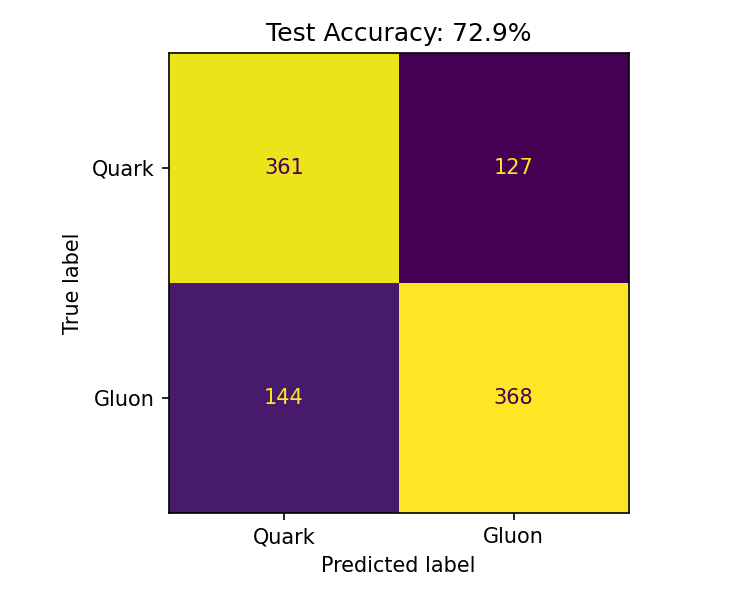
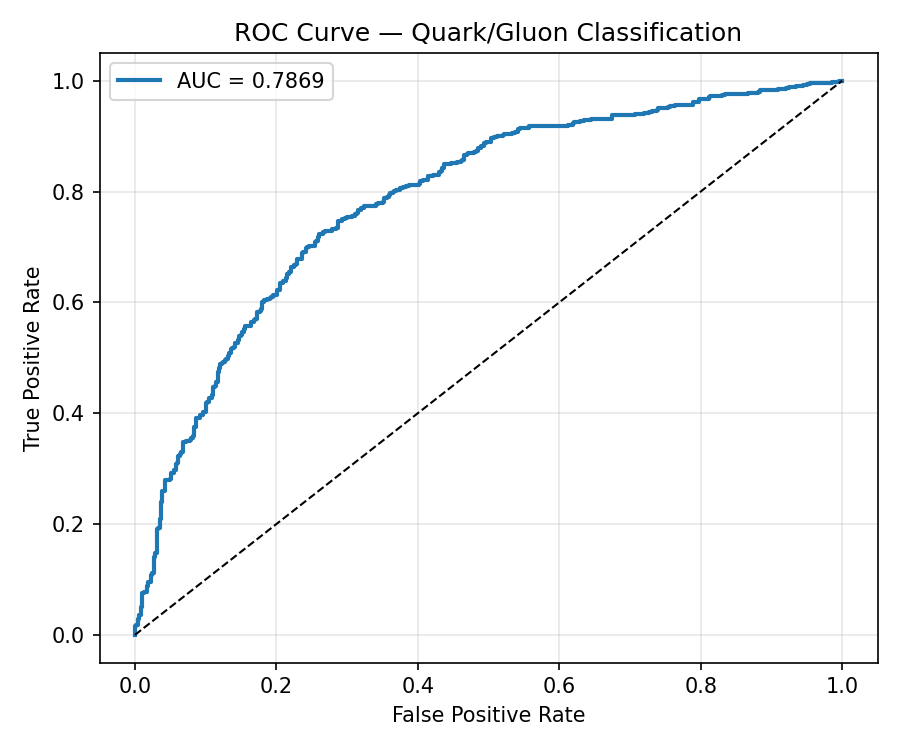
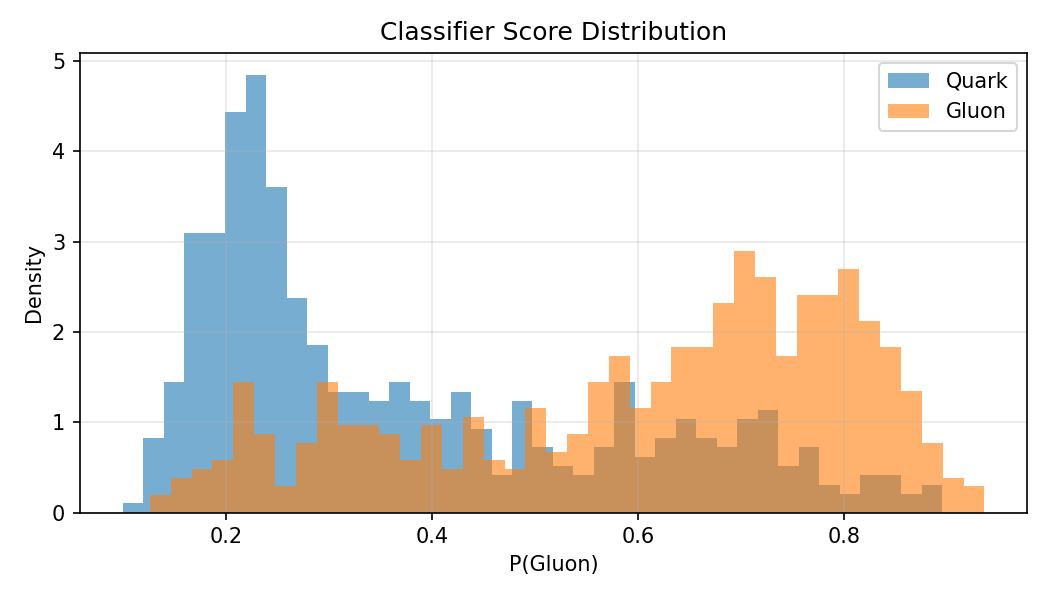